# **Projeto | Pipeline de Dados | AWS - Telegram**

## **1. Introdução**

### **1.1 Objetivo**

 O objetivo deste projeto é construir um pipeline de dados que ingira, processe, armazene e exponha mensagens de um grupo do Telegram para que profissionais de dados possam realizar análises. A arquitetura proposta é dividida em duas: transacional, no Telegram, na qual os dados são produzidos, e analítica, na Amazon Web Services (AWS), onde os dados são analisados.

### **1.2 Arquitetura do projeto**

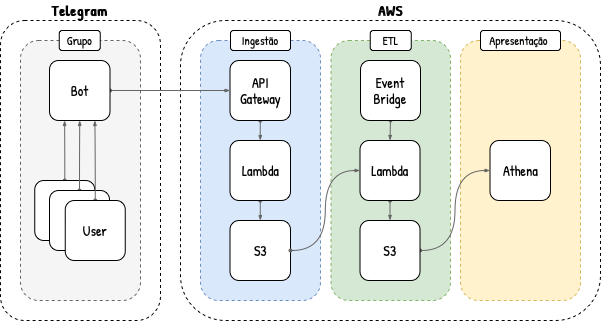

* **Telegram**

O `Telegram` representa a fonte de dados transacionais. Mensagens enviadas por usuários em um grupo são capturadas por um *bot* e redirecionadas via *webhook* do *backend* do aplicativo para um *endpoint* (endereço *web* que aceita requisições HTTP) exposto pelo `AWS API Gateway`. As mensagens trafegam no corpo ou *payload* da requisição.

* **AWS | Ingestão**

Uma requisição HTTP com o conteúdo da mensagem em seu *payload* é recebida pelo `AWS API Gateway` que, por sua vez, as redireciona para o `AWS Lambda`, servindo assim como seu gatilho. Já o `AWS Lambda` recebe o *payload* da requisição em seu parâmetro *event*, salva o conteúdo em um arquivo no formato JSON (original, mesmo que o *payload*) e o armazena no `AWS S3` particionado por dia.

* **AWS | ETL**

Uma vez ao dia, o `AWS Event Bridge` aciona o `AWS Lambda` que processa todas as mensagens do dia anterior (atraso de um dia ou D-1), denormaliza o dado semi-estruturado típico de arquivos no formato JSON, salva o conteúdo processado em um arquivo no formato Apache Parquet e o armazena no `AWS S3` particionado por dia.

* **AWS | Apresentação**

Por fim, uma tabela do `AWS Athena` é apontada para o *bucket* do `AWS S3` que armazena o dado processado: denormalizado, particionado e orientado a coluna. Profissionais de dados podem então executar consultas analíticas (agregações, ordenações, etc.) na tabela utilizando o SQL para a extração de *insights*.

## **2. Sistema Transacional**

> Um sistema transacional é uma estrutura tecnológica e de dados que suporta as transações diárias de uma fonte de dados. Ele é responsável por coletar, registrar e transmitir dados para uma cadeia de processos que tratarão os dados para posterior análise. Em resumo, os sistemas transacionais são projetados para ingerir dados criados diariamente e salvá-los em um banco de dados ou *DataLake*.

### **2.1 Telegram**

O **Telegram** representa a fonte transacional de dados do nosso *pipeline* de dados. Esta etapa consiste em criar um grupo, criar um **bot** e adicioná-lo ao grupo recém criado. O *bot* então captará **todas** as mensagens enviadas no grupo. As mensagens pode ser acessadas através da API (*application programming interface*) de *bots* do **Telegram** (documentação neste [link](https://core.telegram.org/bots/api)).

#### **2.1.1 Criação do *bot***

Na plataforma web do Telegram foi criado um *bot* a partir do *BotFather* e dado o nome de ***exercicio_m43_ebac_rafa_bot***.

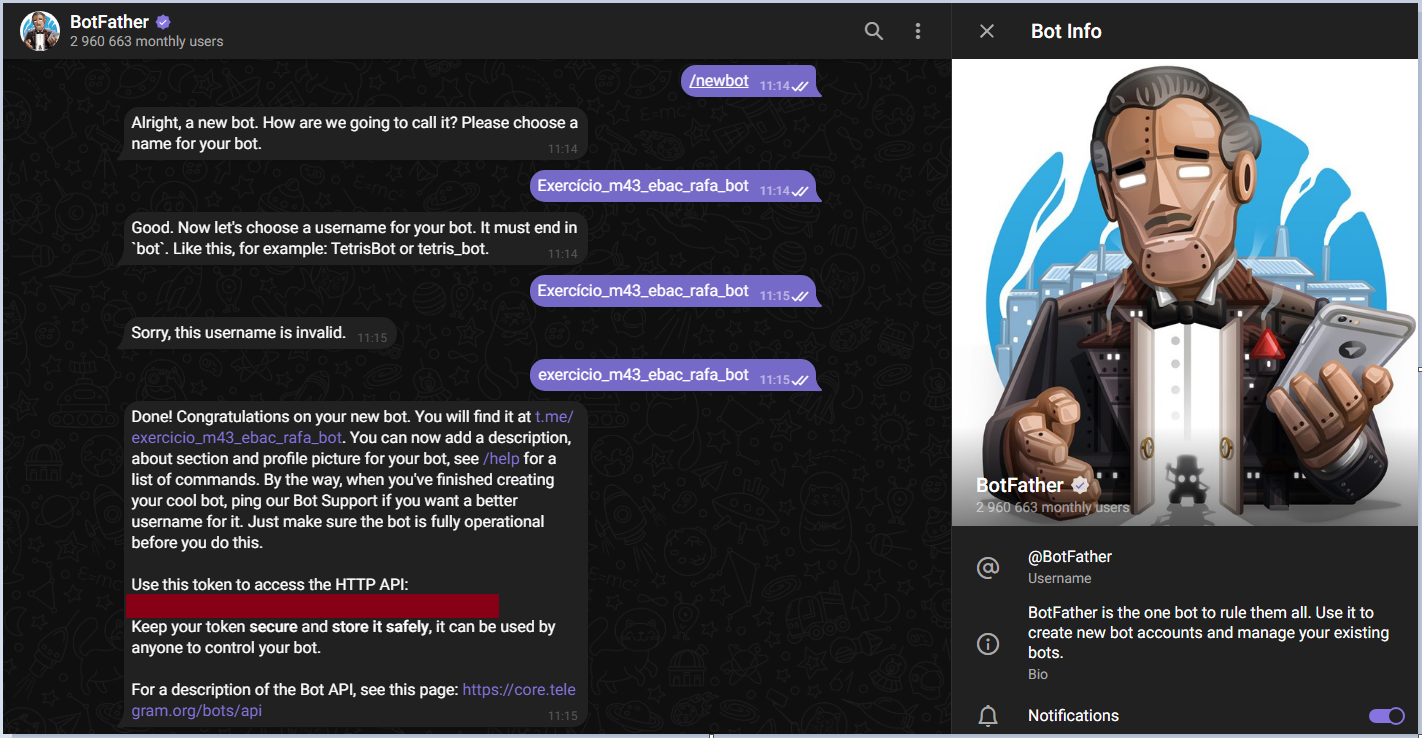

Após a criação do bot, criou-se o grupo que será o objeto de interesse deste projeto, a partir do qual serão captadas as interações entre os integrantes. Em seguida configurou-se o bot recém criado como administrador, permitindo que o mesmo possa coletar todas as mensagens enviadas.

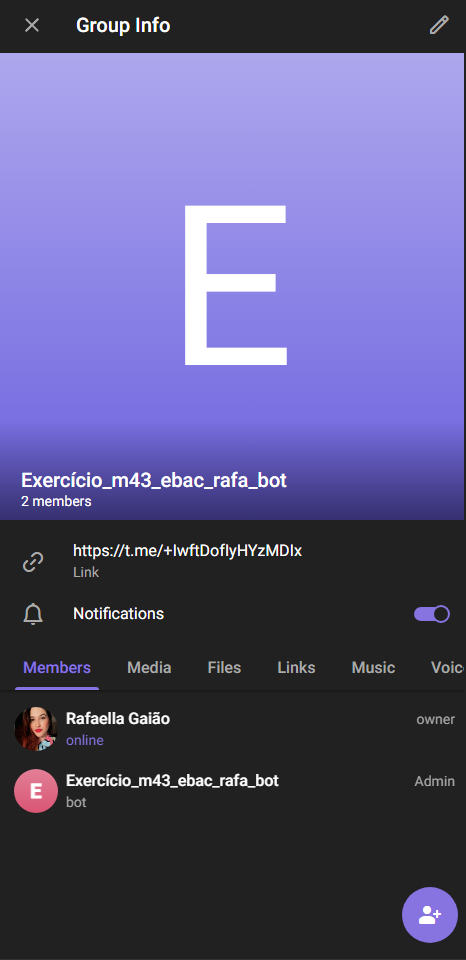

#### **2.1.2 *Bot* API**

As mensagens captadas por um *bot* podem ser acessadas via API. A única informação necessária é o `token` de acesso fornecido pelo `BotFather` na criação do *bot*.

> **Nota:** A documentação completa da API pode ser encontrada neste [link](https://core.telegram.org/bots/api)

In [2]:
from getpass import getpass

token = getpass()

··········


A `url` base é comum a todos os métodos da API.

In [3]:
import json

import requests

base_url = f'https://api.telegram.org/bot{token}'

* **getMe**

O método `getMe` retorna informações sobre o *bot*.

In [4]:
response = requests.get(url=f'{base_url}/getMe')
print(f'{base_url}/getMe')

print(json.dumps(json.loads(response.text), indent=2))

https://api.telegram.org/bot7880487523:AAGyNNePUZnHmi0AZRVHuPCfVcpzvMkvKNw/getMe
{
  "ok": true,
  "result": {
    "id": 7880487523,
    "is_bot": true,
    "first_name": "Exerc\u00edcio_m43_ebac_rafa_bot",
    "username": "exercicio_m43_ebac_rafa_bot",
    "can_join_groups": false,
    "can_read_all_group_messages": false,
    "supports_inline_queries": false,
    "can_connect_to_business": false,
    "has_main_web_app": false
  }
}


### **2.2 AWS | Ingestão**

A etapa de **ingestão** é responsável, como seu o próprio nome diz, pela ingestão dos dados transacionais em ambientes analíticos. De maneira geral, o dado ingerido é persistido no formato mais próximo do original, ou seja, nenhuma transformação é realizada em seu conteúdo ou estrutura (*schema*). Como exemplo, dados de uma API *web* que segue o formato REST (*representational state transfer*) são entregues, logo, persistidos, no formato JSON.

> Persistir os dados em seu formato original trás muitas vantagens, como a possibilidade de reprocessamento.

No projeto, as mensagens capturadas pelo *bot* podem ser ingeridas através da API *web* de *bots* do **Telegram**, portanto são fornecidos no formato JSON. Como o **Telegram** retem mensagens por apenas 24h em seus servidores, a ingestão via **streaming** é a mais indicada. Para que seja possível esse tipo de **ingestão**, utiliza-se um *webhook* (gancho *web*), ou seja, o redirecionamento das mensagens automaticamente para outra API *web*.

Sendo assim, para receber os dados redirecionados, optou-se pelo uso do `AWS API Gateway` (documentação neste [link](https://docs.aws.amazon.com/pt_br/apigateway/latest/developerguide/welcome.html)). Dentre suas diversas funcionalidades, o `AWS API Gateway` permite o redirecionamento do dado recebido para outros serviços da AWS.

Faz-se necessário então o seguinte processo:

 - Criar um *bucket* no `AWS S3`;
 - Criar uma função no `AWS Lambda`;
 - Criar uma API *web* no `AWS API Gateway`;
 - Configurar o *webhook* da API de *bots* do **Telegram**.

#### **2.2.1 AWS S3**

Na etapa de **ingestão**, o `AWS S3` tem a função de passivamente armazenar as mensagens captadas pelo *bot* do **Telegram** no seu formato original: JSON. Para tanto, basta a criação de um *bucket*.

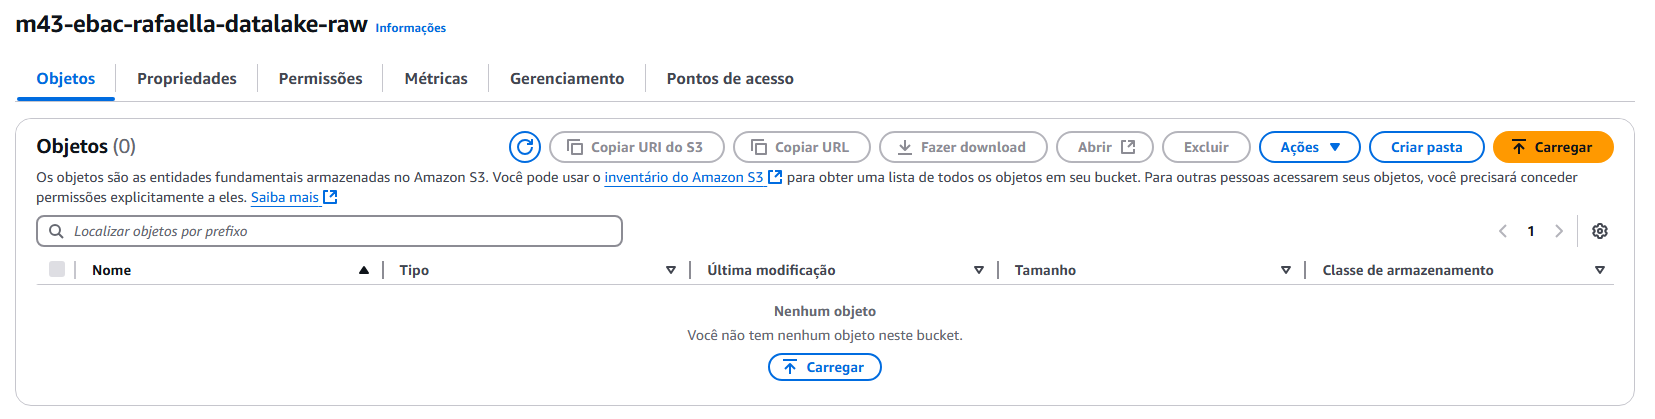

#### **2.2.2 AWS Lambda**

Na etapa de **ingestão**, o `AWS Lambda` tem a função de ativamente persistir as mensagens captadas pelo *bot* do **Telegram** em um *bucket* do `AWS S3`. Para tanto criou-se uma função que opera da seguinte forma:

 - Recebe a mensagem no parâmetro `event`;
 - Verifica se a mensagem tem origem no grupo do **Telegram** correto;
 - Persiste a mensagem no formato JSON no *bucket* do `AWS S3`;
 - Retorna uma mensagem de sucesso (código de retorno HTTP igual a 200) a API de *bots* do **Telegram**.

O código da função:

In [ ]:
import os
import json
import logging
from datetime import datetime, timezone

import boto3


def lambda_handler(event: dict, context: dict) -> dict:

  '''
  Recebe uma mensagens do Telegram via AWS API Gateway, verifica no
  seu conteúdo se foi produzida em um determinado grupo e a escreve,
  em seu formato original JSON, em um bucket do AWS S3.
  '''

  # vars de ambiente

  BUCKET = os.environ['AWS_S3_BUCKET']
  TELEGRAM_CHAT_ID = int(os.environ['TELEGRAM_CHAT_ID'])

  # vars lógicas

  tzinfo = timezone(offset=timedelta(hours=-3))
  date = datetime.now(tzinfo).strftime('%Y-%m-%d')
  timestamp = datetime.now(tzinfo).strftime('%Y%m%d%H%M%S%f')

  filename = f'{timestamp}.json'

  # código principal

  client = boto3.client('s3')

  try:

    message = json.loads(event["body"])
    chat_id = message["message"]["chat"]["id"]

    if chat_id == TELEGRAM_CHAT_ID:

      with open(f"/tmp/{filename}", mode='w', encoding='utf8') as fp:
        json.dump(message, fp)

      client.upload_file(f'/tmp/{filename}', BUCKET, f'telegram/context_date={date}/{filename}')

  except Exception as exc:
      logging.error(msg=exc)
      return dict(statusCode="500")

  else:
      return dict(statusCode="200")

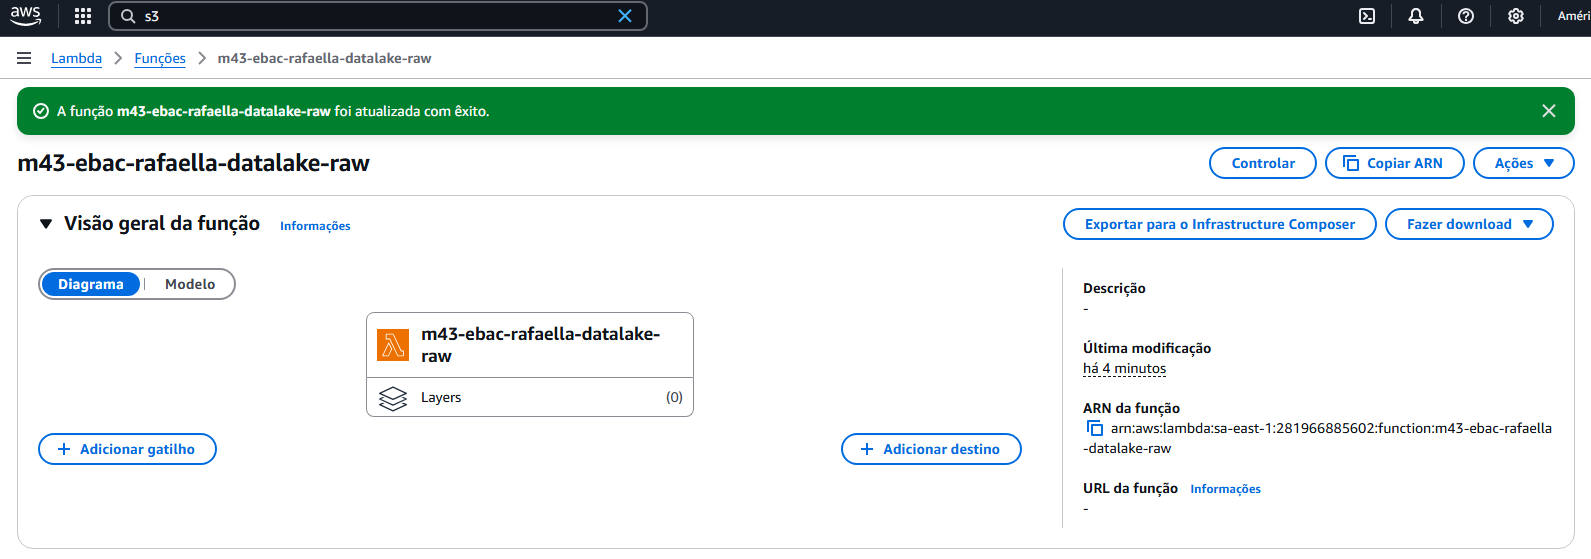

Para que a função funcione corretamente, algumas configurações precisam ser realizadas.

 - **Variáveis de ambiente**

O código exige a configuração de duas variáveis de ambiente: `AWS_S3_BUCKET` com o nome do *bucket* do `AWS S3` e `TELEGRAM_CHAT_ID` com o id do *chat* do grupo do **Telegram**.

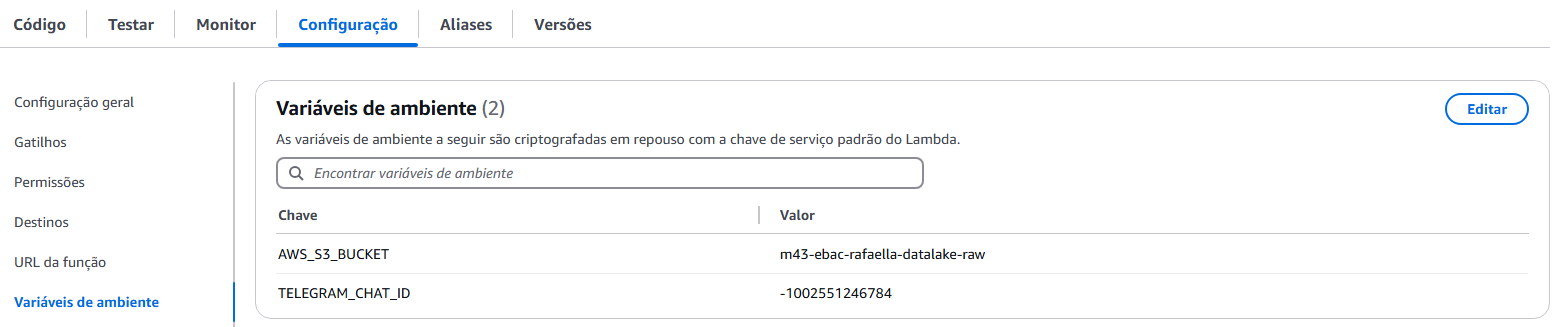

 - **Permissão**

Por fim, precisa-se adicionar a permissão de escrita no *bucket* do `AWS S3` para a função do `AWS Lambda` no `AWS IAM`.

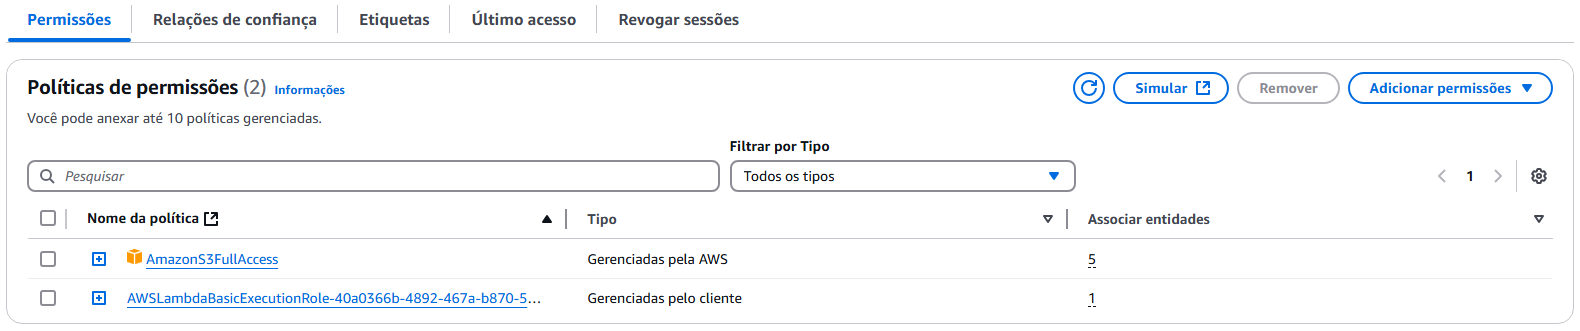

* **Teste da Função Lambda**

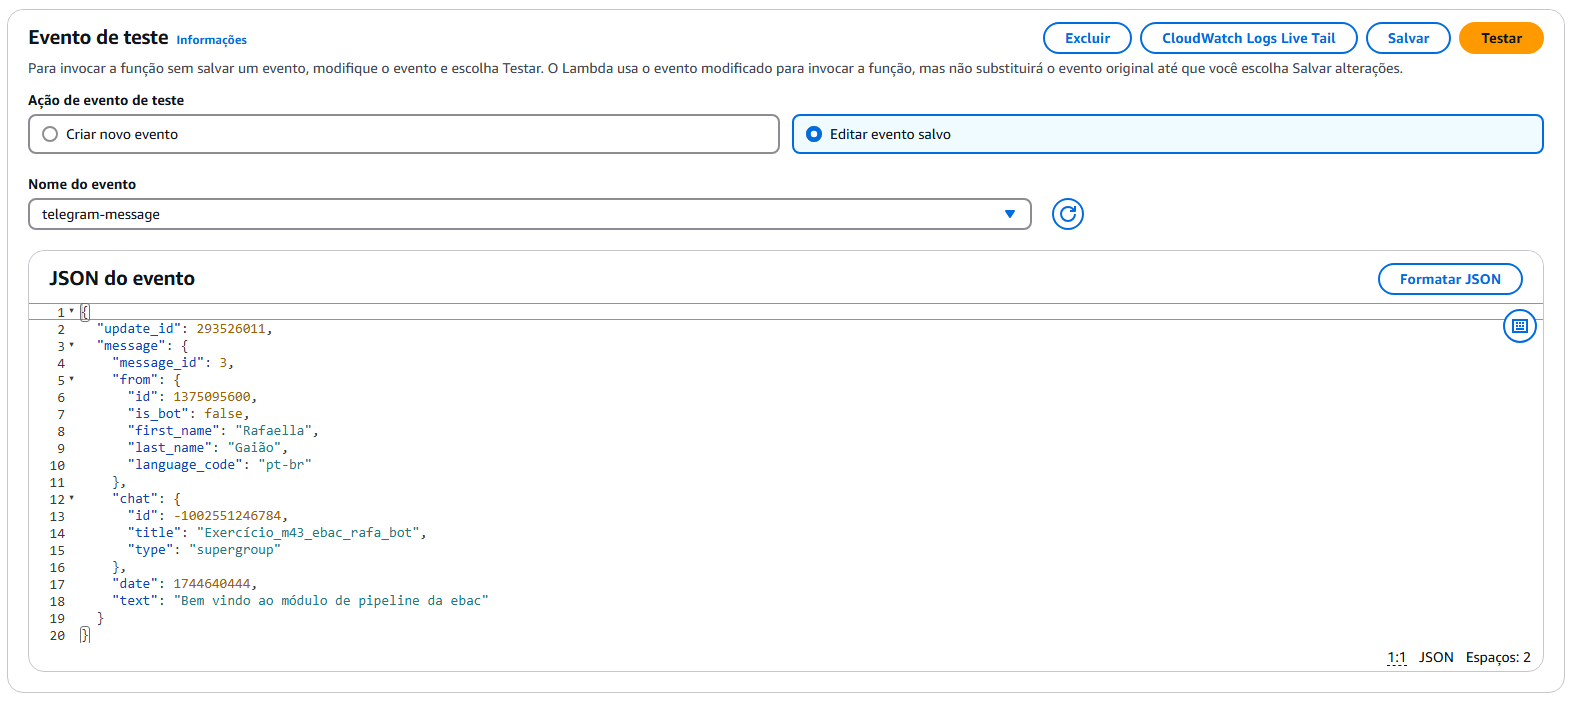

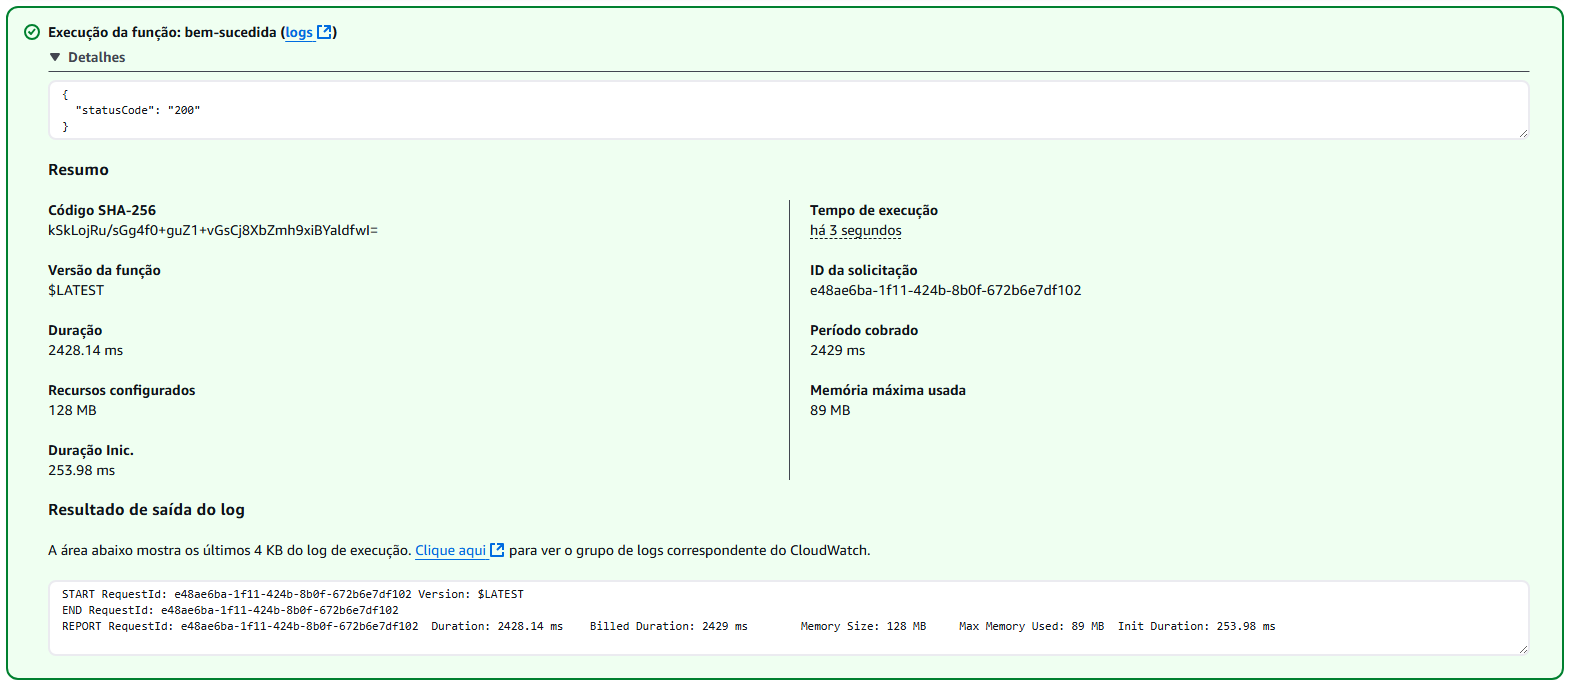

#### **2.2.3 AWS API Gateway**

Na etapa de **ingestão**, o `AWS API Gateway` tem a função de receber as mensagens captadas pelo *bot* do **Telegram**, enviadas via *webhook*, e iniciar uma função do `AWS Lambda`, passando o conteúdo da mensagem no seu parâmetro *event*. Para tanto criou-se uma API para configurá-la como gatilho da função do `AWS Lambda`.

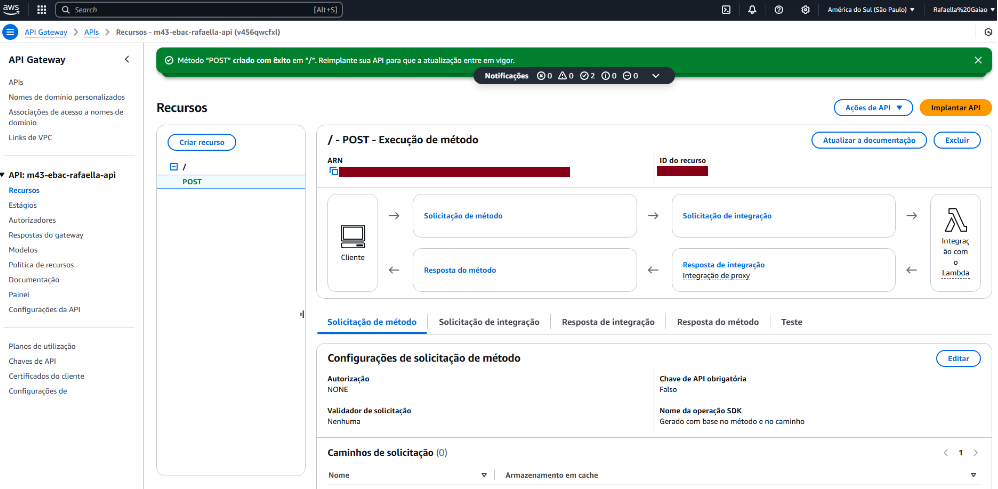

Testou-se a integração com o `AWS Lambda` através da ferramenta de testes do serviço. Por fim, fez-se a implantação da API para obter o seu endereço *web*.

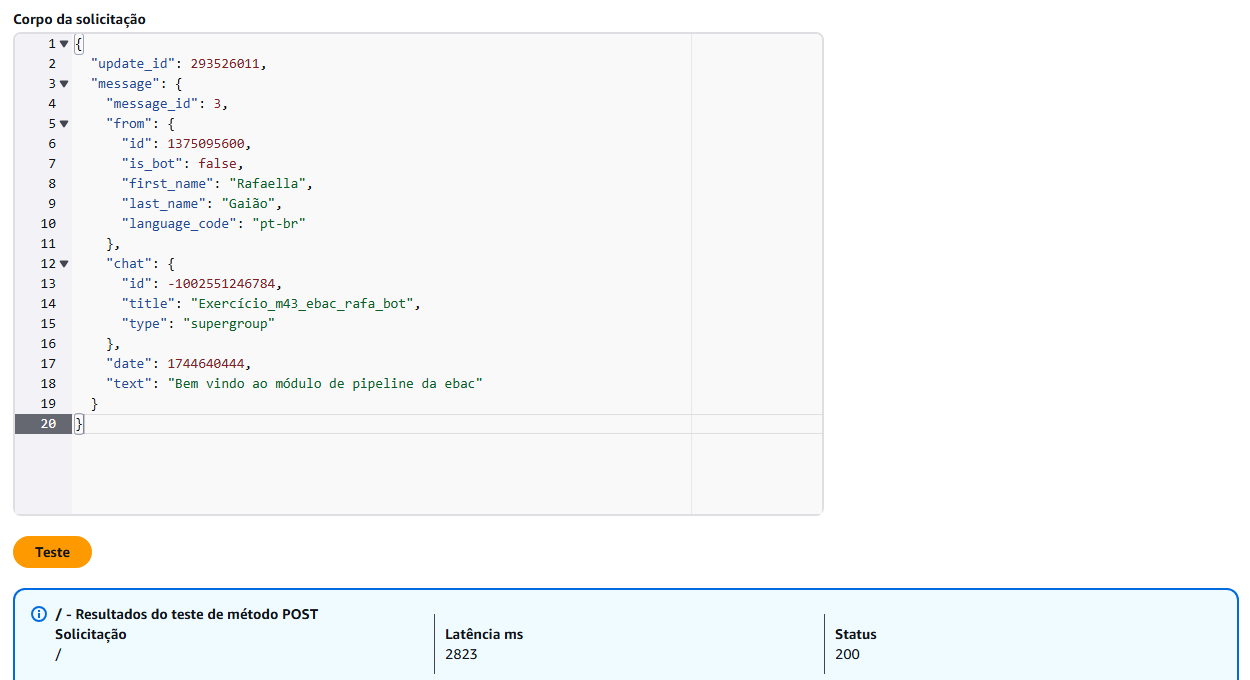

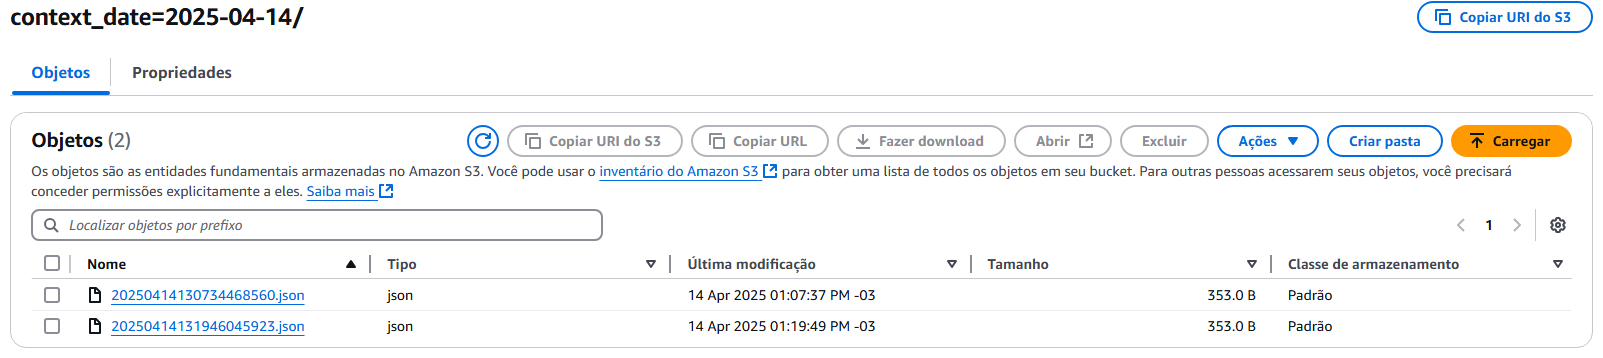

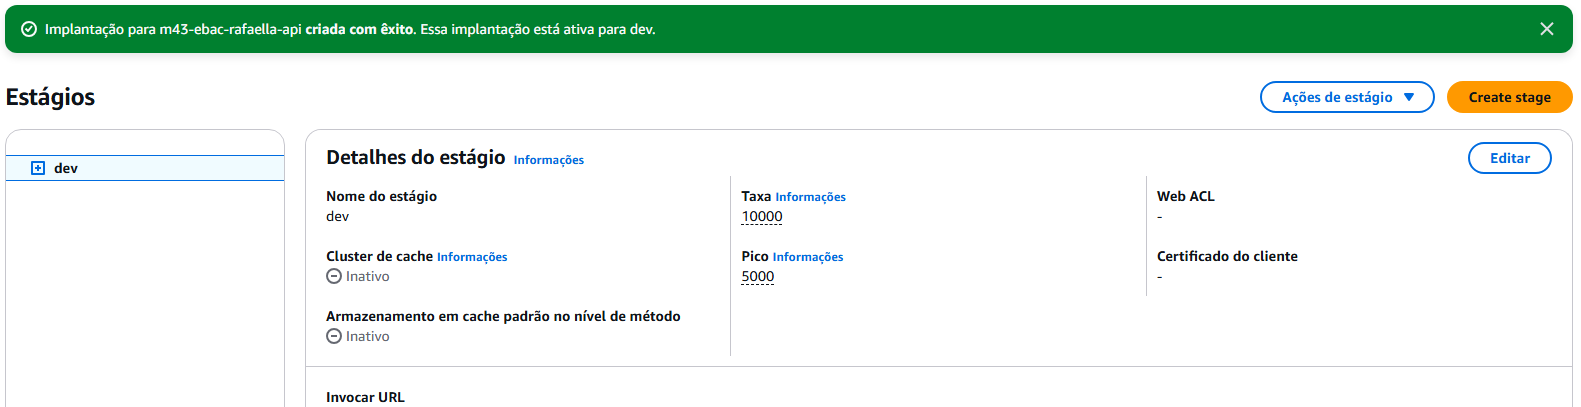

Copie o a `url` gerada na variável `aws_api_gateway_url`.

In [5]:
aws_api_gateway_url = getpass()

··········


#### **2.2.4 *Webhook***

Configuração do *webhook* para redirecionar as mensagens para a `url` do `AWS API Gateway`.

 - **setWebhook**

O método `setWebhook` configura o redirecionamento das mensagens captadas pelo *bot* para o endereço *web* do paramametro `url`.

In [6]:
response = requests.get(url=f'{base_url}/setWebhook?url={aws_api_gateway_url}')

print(json.dumps(json.loads(response.text), indent=2))

{
  "ok": true,
  "result": true,
  "description": "Webhook is already set"
}


 - **getWebhookInfo**

O método `getWebhookInfo` retorna as informações sobre o *webhook* configurado.

In [7]:
response = requests.get(url=f'{base_url}/getWebhookInfo')

print(json.dumps(json.loads(response.text), indent=2))

{
  "ok": true,
  "result": {
    "url": "https://v456qwcfxl.execute-api.sa-east-1.amazonaws.com/dev",
    "has_custom_certificate": false,
    "pending_update_count": 0,
    "max_connections": 40,
    "ip_address": "18.229.111.63"
  }
}


## **3. Sistema Analítico**

> Esse sistema apoia a tomada de decisões, relatórios, consultas e análises. É projetado para lidar com consultas complexas em grandes volumes de dados vindos dos sistemas transacionais, organiza esses dados e os processam de maneira a criar insights úteis. Neste projeto o sistema compreende a retirada dos dados brutos (raw) do *DataLake*, a transformação deles em informação e a análise em busca de padrões e insights.

### **3.1 AWS | ETL**

A etapa de **extração, transformação e carregamento** (do inglês *extraction, transformation and load* ou **ETL**) é uma etapa abrangente responsável pela manipulação dos dados ingeridos de sistemas transacionais, ou seja, já persistidos em camadas cruas ou *raw* de sistemas analíticos. Os processos conduzidos nesta etapa variam bastante de acordo com a área da empresa, do volume/variedade/velocidade do dado consumido, etc. Contudo, em geral, o dado cru ingerido passa por um processo recorrente de *data wrangling* onde o dado é limpo, deduplicado, etc. e persistido com técnicas de particionamento, orientação a coluna e compressão. Por fim, o dado processado está pronto para ser analisado por profissionais de dados.

No projeto, as mensagens de um único dia, persistidas na camada cru, serão compactas em um único arquivo, orientado a coluna e comprimido, que será persistido em uma camada enriquecida. Além disso, durante este processo, o dado também passará por etapas de *data wrangling*.

Para isso, utilizou-se uma função do `AWS Lambda` como motor de processamento e um *bucket* do `AWS S3` como camada enriquecida para a persistência do dado processado. Para garantir a recorrência, configurou-se uma regra do `AWS Event Bridge` como gatilho diáro da função.

#### **3.1.1 AWS S3**

Na etapa de **ETL**, o `AWS S3` tem a função de passivamente armazenar as mensagens processadas de um dia em um único arquivo no formato Parquet. Para tanto, basta a criação de um *bucket*.

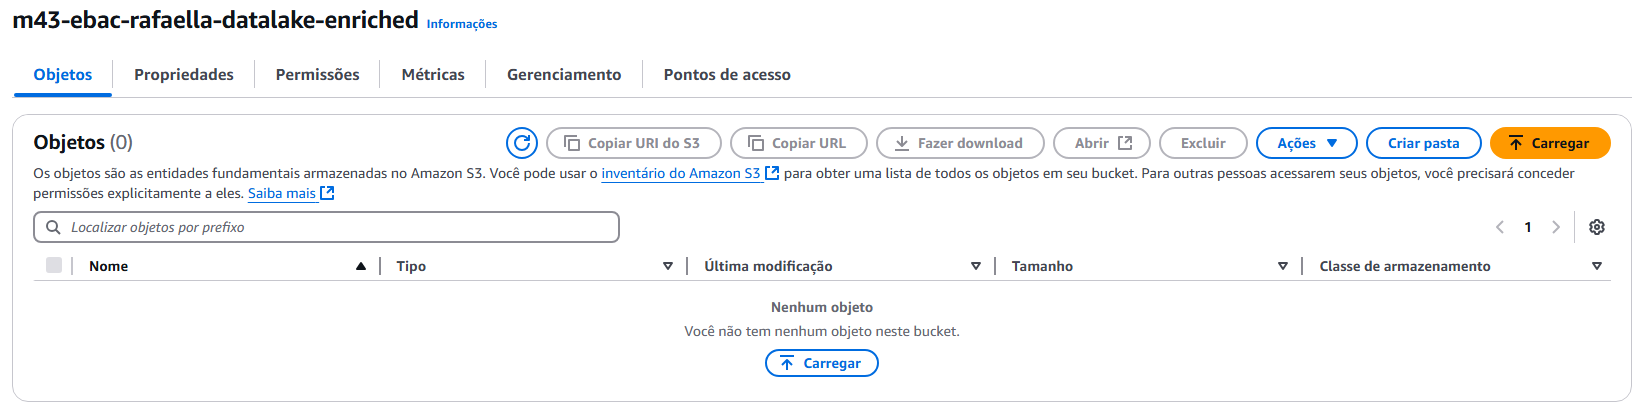

#### **3.1.2 AWS Lambda**

Na etapa de **ETL**, o `AWS Lambda` tem a função de ativamente processar as mensagens captadas pelo *bot* do **Telegram**, persistidas na camada cru no *bucket* do `AWS S3`, e persisti-las na camada enriquecida, também em um *bucket* do `AWS S3`. Logo, vamos criou-se uma função que opera da seguinte forma:

 - Lista todos os arquivos JSON de uma única participação da camada crua de um *bucket* do `AWS S3`;
 - Para cada arquivo listado:
  - Faz o *download* do arquivo e carrega o conteúdo da mensagem;
  - Executa uma função de *data wrangling*;
  - Cria uma tabela do PyArrow e a contatena com as demais.
 - Persiste a tabela no formato Parquet na camada enriquecida em um *bucket* do `AWS S3`.

> **Nota**: O fato de utilizar duas camadas de armazenamento e processamento, permite que se possa reprocessar os dados crus de diversas maneiras, quantas vezes forem preciso.

O código da função:

In [ ]:
import os
import json
import logging
from datetime import datetime, timedelta, timezone

import boto3
import pyarrow as pa
import pyarrow.parquet as pq


def lambda_handler(event: dict, context: dict) -> bool:

  '''
  Diariamente é executado para compactar as diversas mensagensm, no formato
  JSON, do dia anterior, armazenadas no bucket de dados cru, em um único
  arquivo no formato PARQUET, armazenando-o no bucket de dados enriquecidos
  '''

  # vars de ambiente

  RAW_BUCKET = os.environ['AWS_S3_BUCKET']
  ENRICHED_BUCKET = os.environ['AWS_S3_ENRICHED']

  # vars lógicas

  tzinfo = timezone(offset=timedelta(hours=-3))
  date = (datetime.now(tzinfo) - timedelta(days=1)).strftime('%Y-%m-%d')
  timestamp = datetime.now(tzinfo).strftime('%Y%m%d%H%M%S%f')

  # código principal

  table = None
  client = boto3.client('s3')

  try:

      response = client.list_objects_v2(Bucket=RAW_BUCKET, Prefix=f'telegram/context_date={date}')

      for content in response['Contents']:

        key = content['Key']
        client.download_file(RAW_BUCKET, key, f"/tmp/{key.split('/')[-1]}")

        with open(f"/tmp/{key.split('/')[-1]}", mode='r', encoding='utf8') as fp:

          data = json.load(fp)
          data = data["message"]

        parsed_data = parse_data(data=data)
        iter_table = pa.Table.from_pydict(mapping=parsed_data)

        if table:

          table = pa.concat_tables([table, iter_table])

        else:

          table = iter_table
          iter_table = None

      pq.write_table(table=table, where=f'/tmp/{timestamp}.parquet')
      client.upload_file(f"/tmp/{timestamp}.parquet", ENRICHED_BUCKET, f"telegram/context_date={date}/{timestamp}.parquet")

      return True

  except Exception as exc:
      logging.error(msg=exc)
      return False

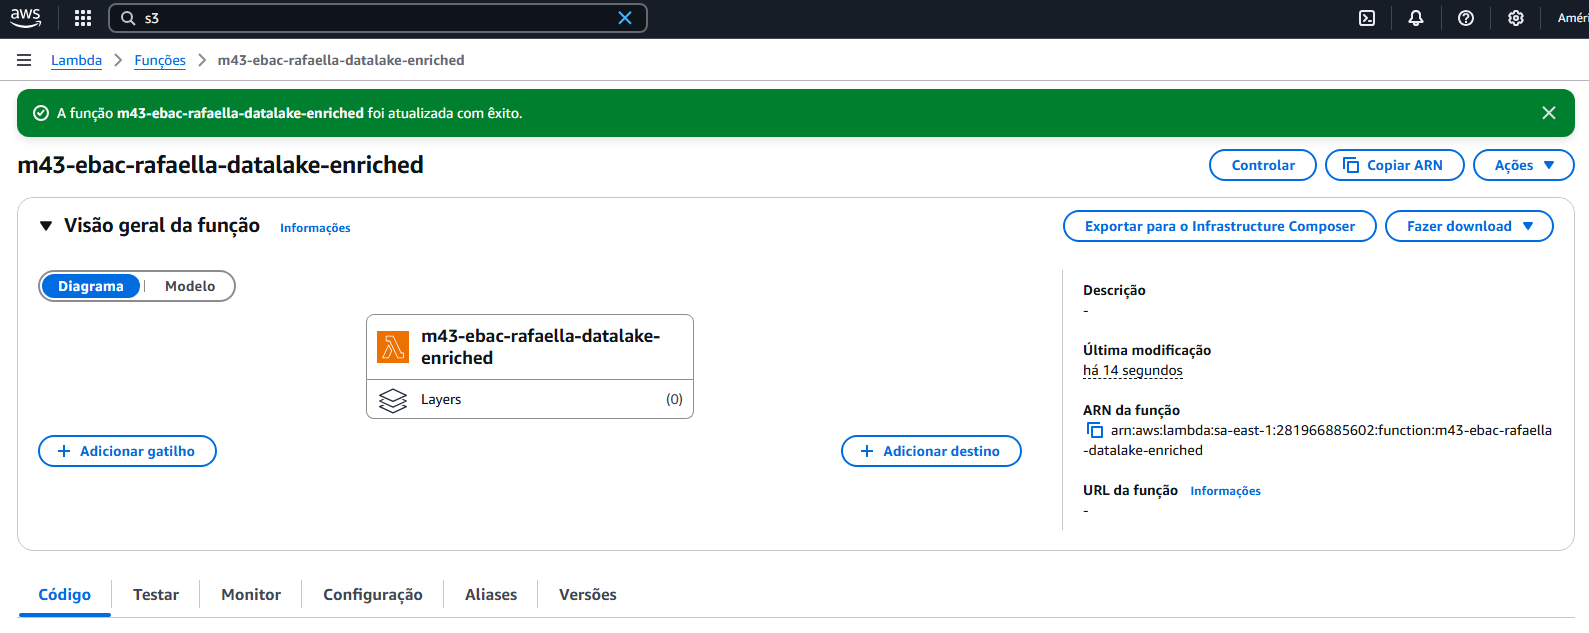

O código da função de *data wrangling*:

In [ ]:
def parse_data(data: dict) -> dict:

  date = datetime.now().strftime('%Y-%m-%d')
  timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

  parsed_data = dict()

  for key, value in data.items():

      if key == 'from':
          for k, v in data[key].items():
              if k in ['id', 'is_bot', 'first_name']:
                parsed_data[f"{key if key == 'chat' else 'user'}_{k}"] = [v]

      elif key == 'chat':
          for k, v in data[key].items():
              if k in ['id', 'type']:
                parsed_data[f"{key if key == 'chat' else 'user'}_{k}"] = [v]

      elif key in ['message_id', 'date', 'text']:
          parsed_data[key] = [value]

  if not 'text' in parsed_data.keys():
    parsed_data['text'] = [None]

  return parsed_data

Para que a função funcione corretamente, algumas configurações precisam ser realizadas.

 - **Variáveis de ambiente**

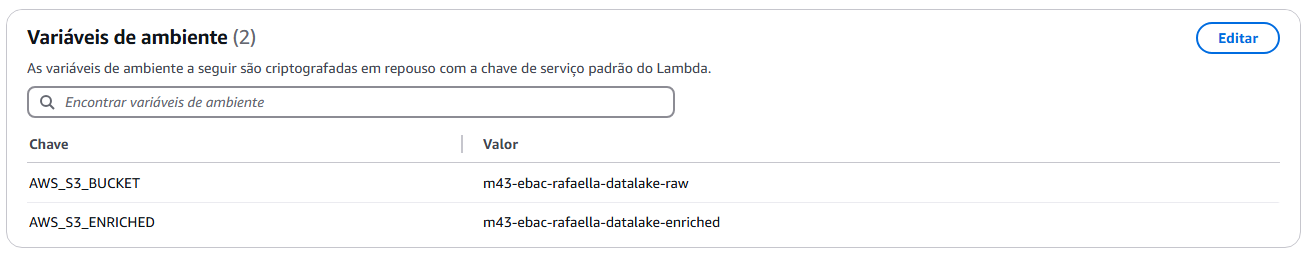

 - **Permissão**

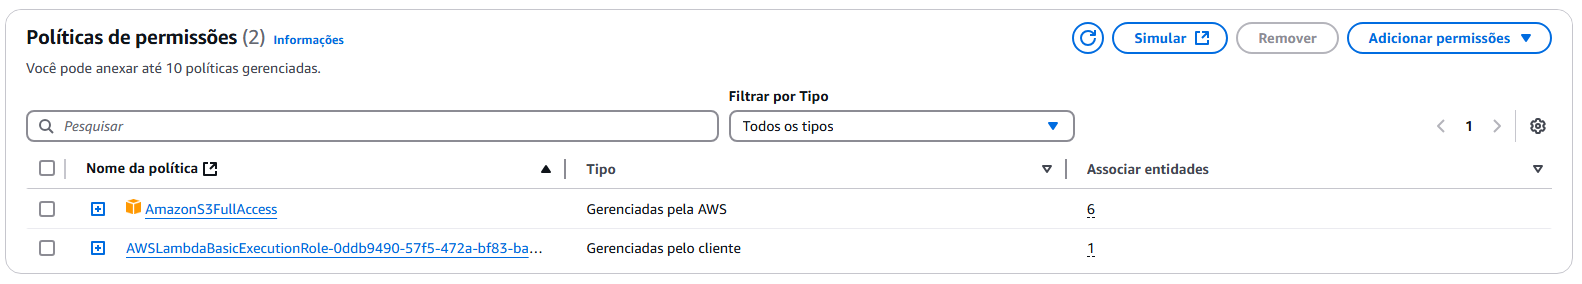

 - **Recursos**

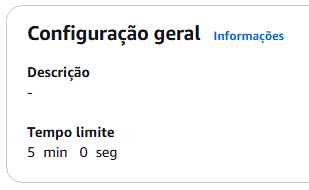

 - **Camadas**

O código da função utiliza o pacote Python PyArrow. Contudo, o ambiente padrão do `AWS Lambda` possui poucos pacotes externos instalado, como o pacote Python boto3, logo o PyArrow não será encontrado e a execução da função falhará. Existem algumas formas de adicionar pacotes externos no ambiente de execução do AWS Lambda, um deles é a criação de camadas ou *layers*, onde pode-se fazer o *upload* dos pacotes Python direto na plataforma ou através de um *bucket* do `AWS S3`.

 - Criar um *bucket* no `AWS S3`;
 - Fazer o *upload* do código do pacote Python do PyArrow (*download* neste [link](https://github.com/awslabs/aws-data-wrangler/releases));
 - Criar *layer* e conectar na função.

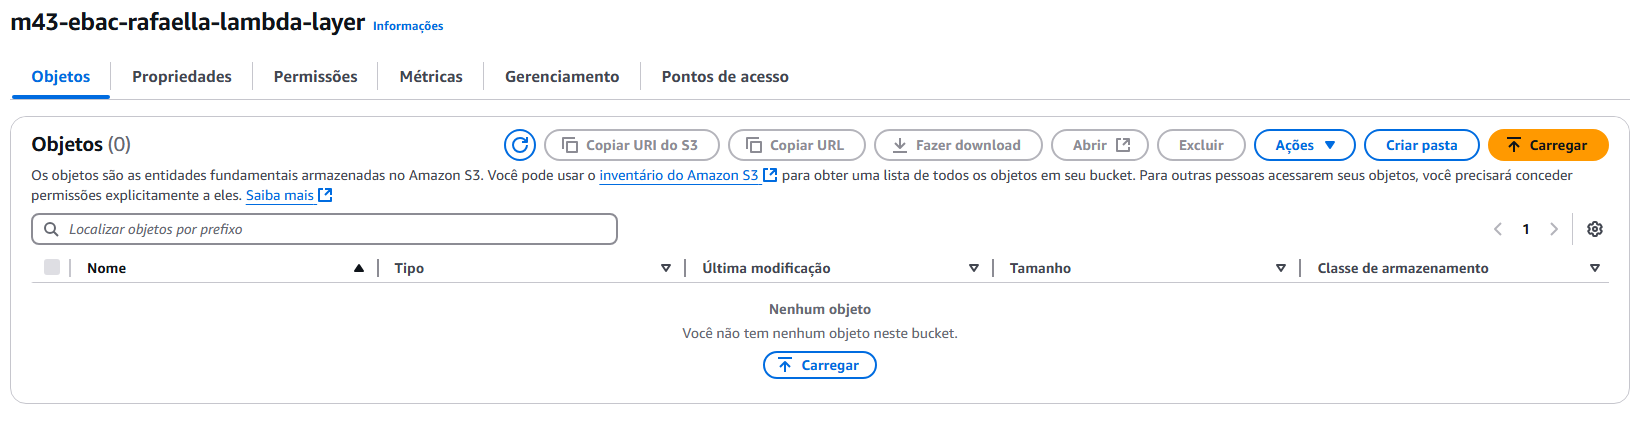

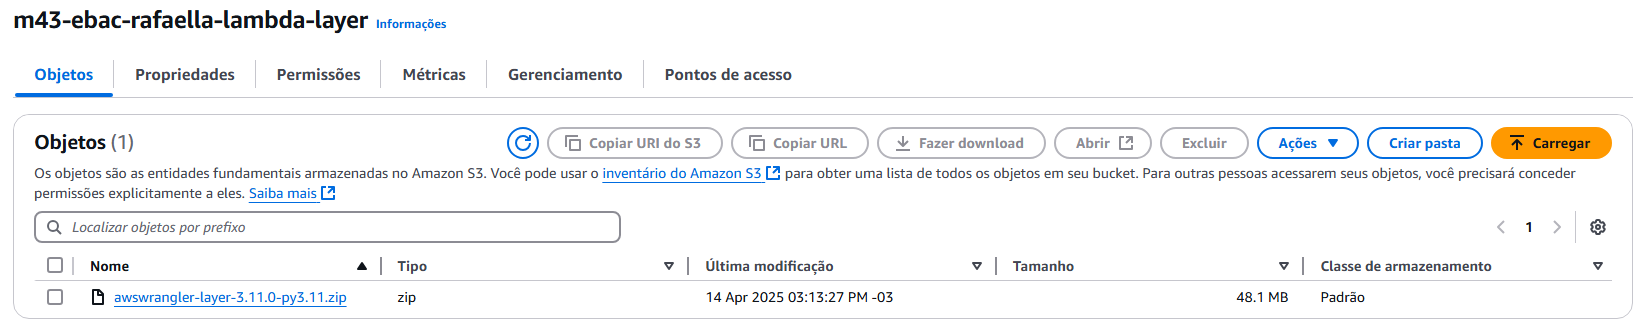

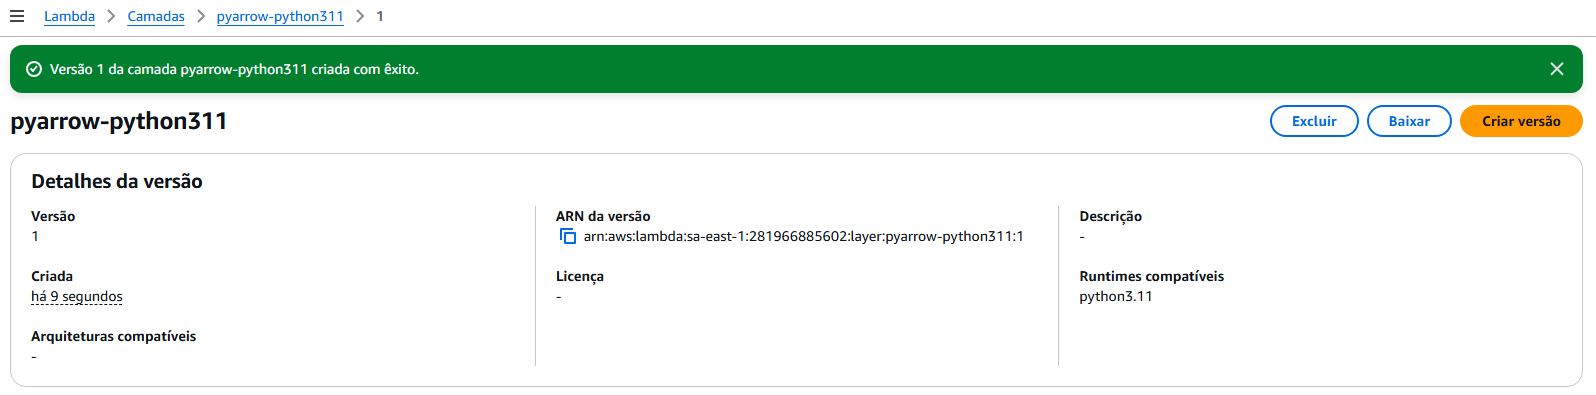

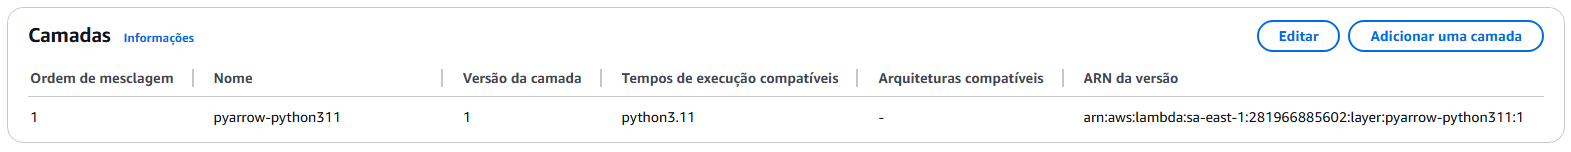

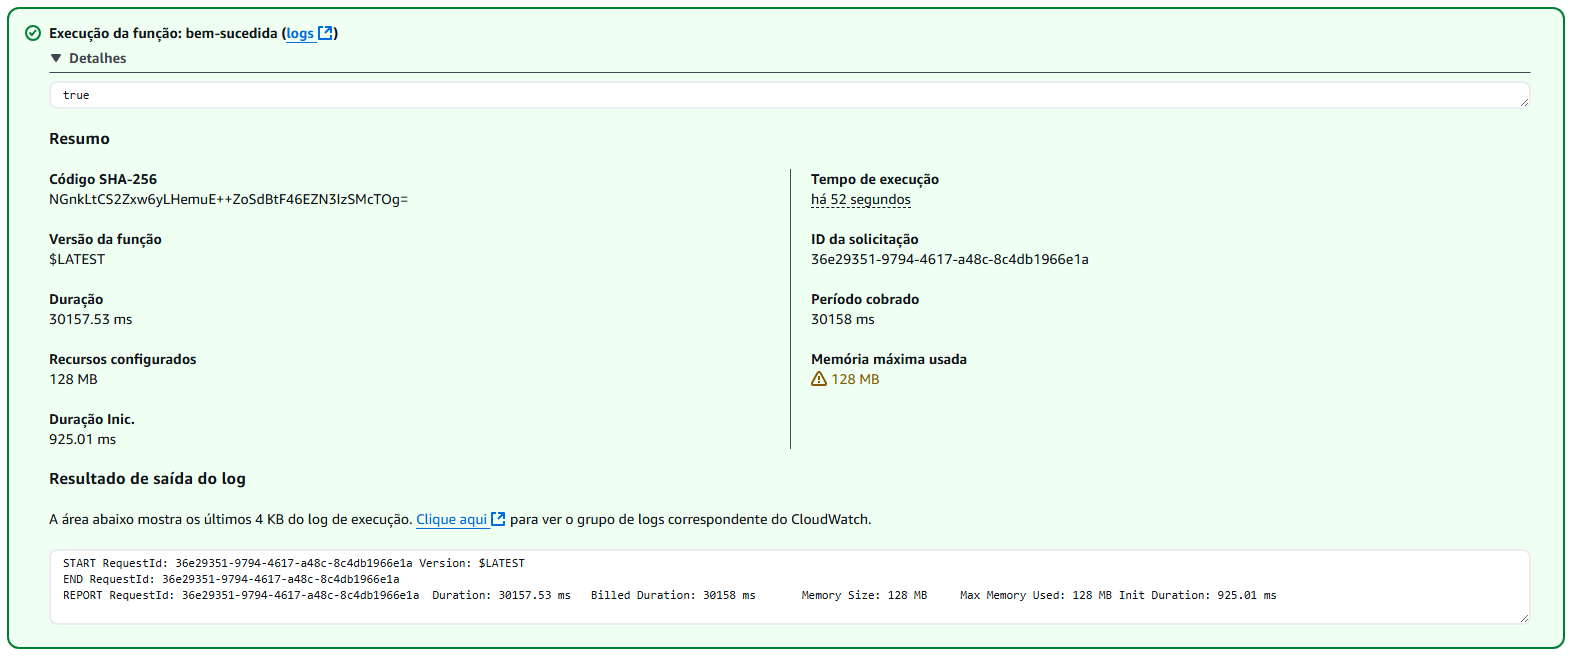

#### **3.1.3 AWS Event Bridge**

Na etapa de **ETL**, o `AWS Event Bridge` tem a função de ativar diariamente a função de **ETL** do `AWS Lambda`, funcionando assim como um *scheduler*.

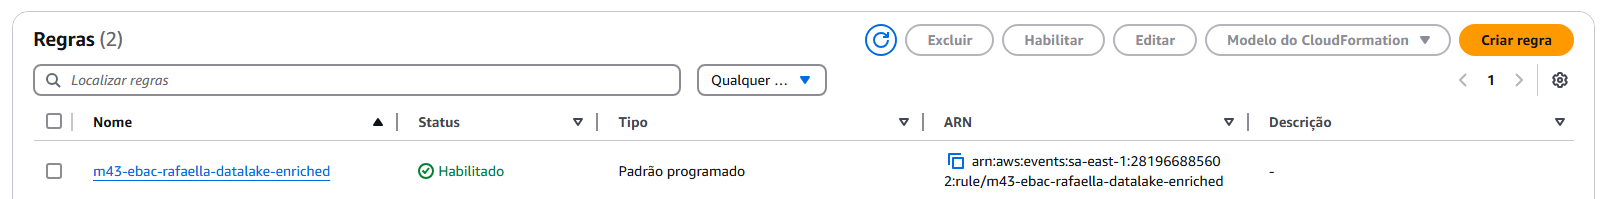

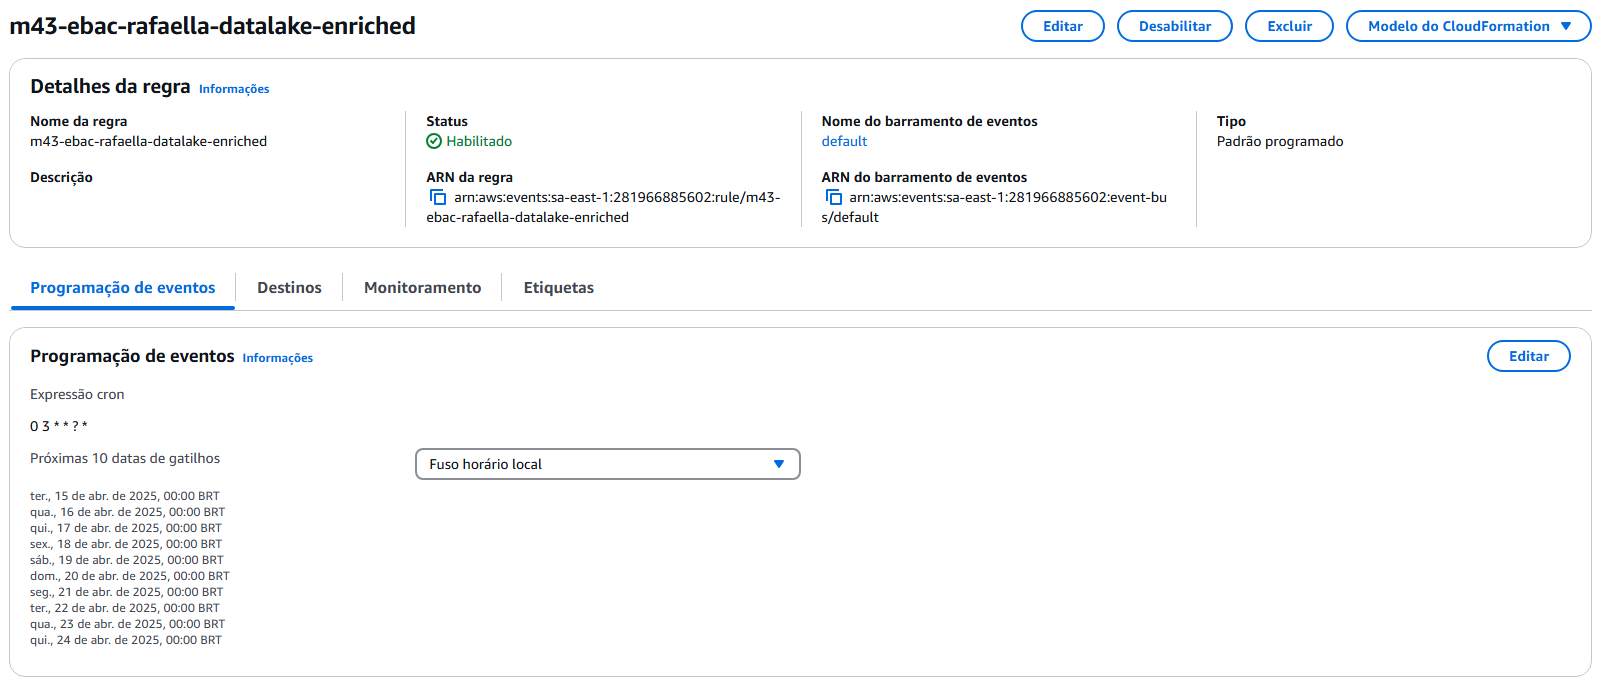

## **4. Apresentação**

A etapa de **apresentação** é reponsável por entregar o dado para os usuários (analistas, cientistas, etc.) e sistemas (dashboards, motores de consultas, etc.), idealmente através de uma interface de fácil uso, como o SQL, logo, essa é a única etapa que a maioria dos usuários terá acesso. Além disso, é importante que as ferramentas da etapa entreguem dados armazenados em camadas refinadas, pois assim as consultas são mais baratas e o dados mais consistentes.

### **4.1 AWS Athena**

Na etapa de **apresentação**, o `AWS Athena` tem função de entregar os dados através de uma interface SQL para os usuários do sistema analítico. Para criar a interface, gerou-se uma tabela externa sobre o dado armazenado na camada mais refinada da arquitetura, a camada enriquecida.

Código:

In [ ]:
CREATE EXTERNAL TABLE `telegram`(
  `message_id` bigint,
  `user_id` bigint,
  `user_is_bot` boolean,
  `user_first_name` string,
  `chat_id` bigint,
  `chat_type` string,
  `text` string,
  `date` bigint)
PARTITIONED BY (
  `context_date` date)
ROW FORMAT SERDE
  'org.apache.hadoop.hive.ql.io.parquet.serde.ParquetHiveSerDe'
STORED AS INPUTFORMAT
  'org.apache.hadoop.hive.ql.io.parquet.MapredParquetInputFormat'
OUTPUTFORMAT
  'org.apache.hadoop.hive.ql.io.parquet.MapredParquetOutputFormat'
LOCATION
  's3://m43-ebac-rafaella-datalake-enriched/telegram/'

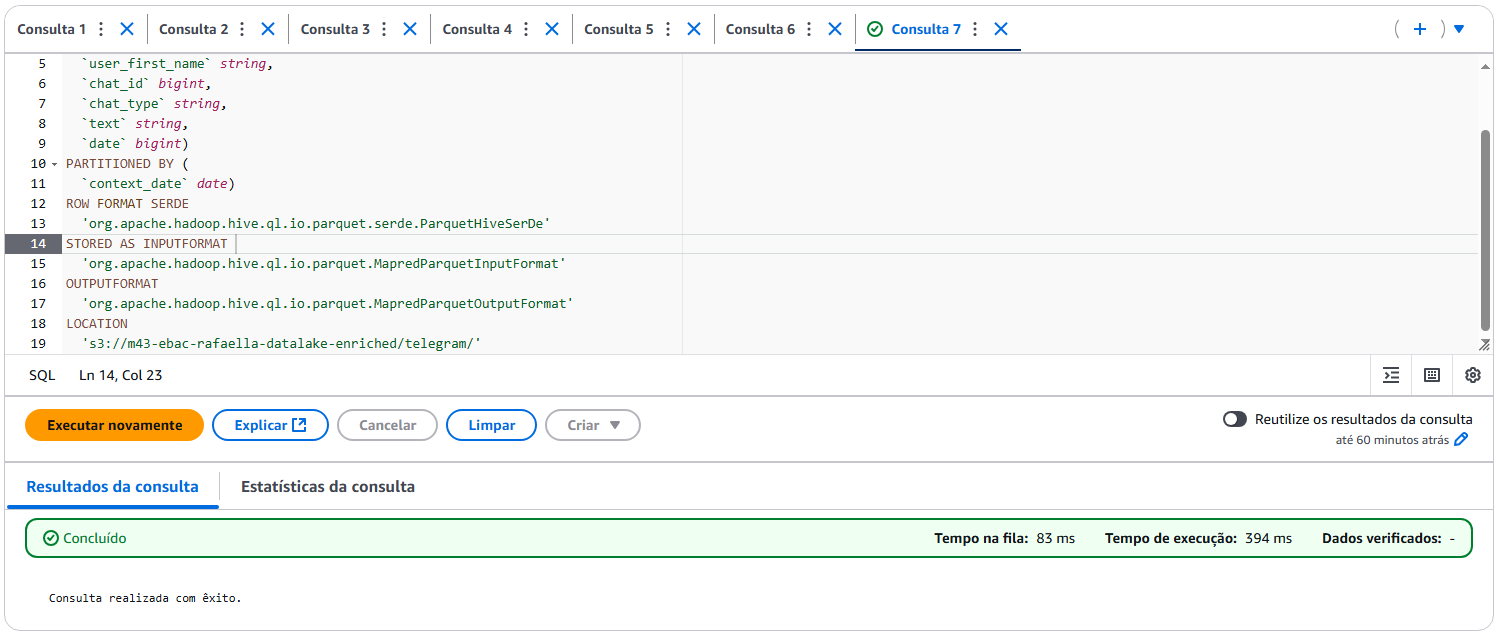

Por fim, adicionou-se as partições disponíveis.

In [ ]:
MSCK REPAIR TABLE `telegram`;

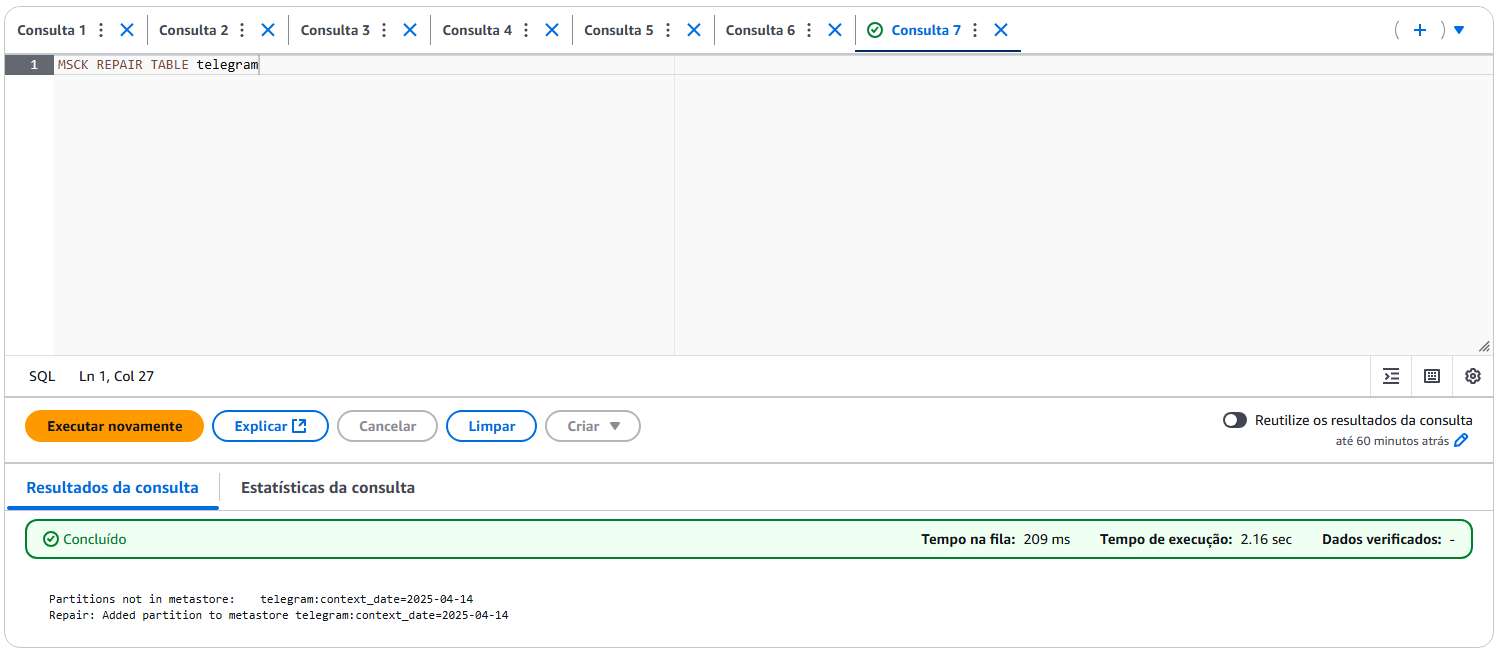

### **4.2 Analytics**

Com o dado disponível, foi possível iniciar a etapa de análise:

- Quantidade de mensagens por dia.

In [ ]:
SELECT
  context_date,
  count(1) AS "message_amount"
FROM "telegram"
GROUP BY context_date
ORDER BY context_date DESC

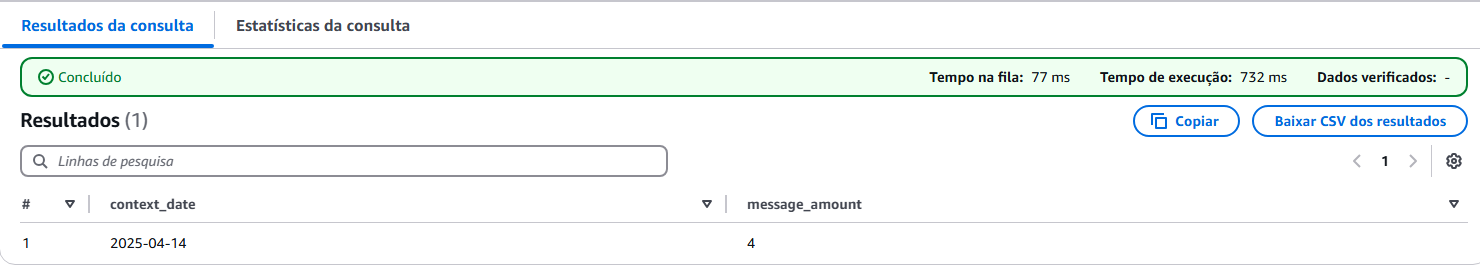

> **Análise:** No dia 14/04/2025 quatro mensagens foram enviadas

- Quantidade de mensagens por usuário por dia.

In [ ]:
SELECT
  user_id,
  user_first_name,
  context_date,
  count(1) AS "message_amount"
FROM "telegram"
GROUP BY
  user_id,
  user_first_name,
  context_date
ORDER BY context_date DESC

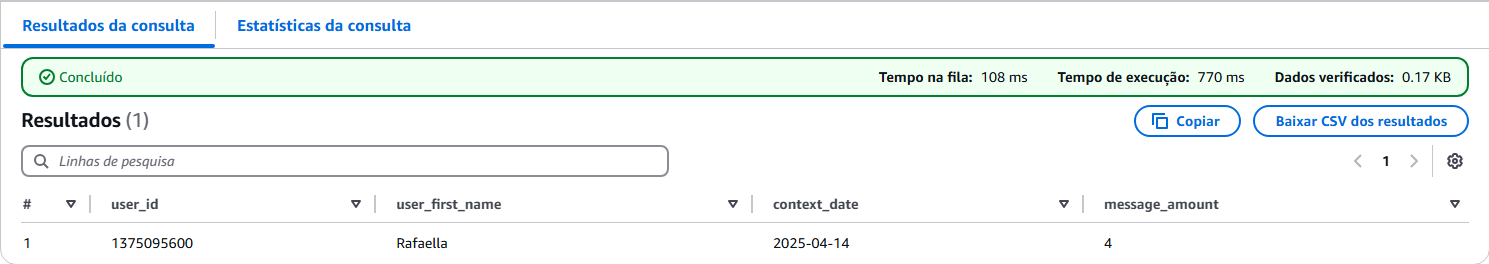

> **Análise:** No dia 14/04/2025 apenas o usuário "Rafaella" enviou mensagem.

- Média do tamanho das mensagens por usuário por dia.

In [ ]:
SELECT
  user_id,
  user_first_name,
  context_date,
  CAST(AVG(length(text)) AS INT) AS "average_message_length"
FROM "telegram"
GROUP BY
  user_id,
  user_first_name,
  context_date
ORDER BY context_date DESC

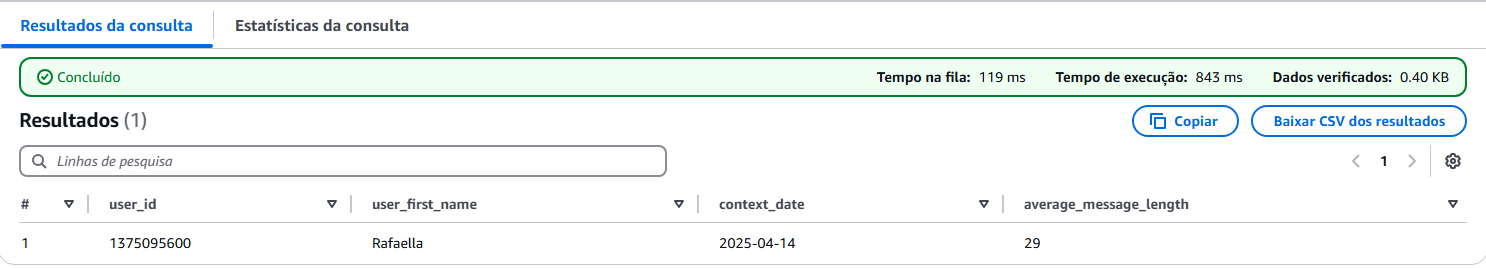

> **Análise:** A médias do tamanho das mensagens no dia 14/04/2025 foi de 29 caracteres.

- Quantidade de mensagens por hora por dia da semana por número da semana.

In [ ]:
WITH
parsed_date_cte AS (
    SELECT
        *,
        CAST(date_format(from_unixtime("date"),'%Y-%m-%d %H:%i:%s') AS timestamp) AS parsed_date
    FROM "telegram"
),
hour_week_cte AS (
    SELECT
        *,
        EXTRACT(hour FROM parsed_date) AS parsed_date_hour,
        EXTRACT(dow FROM parsed_date) AS parsed_date_weekday,
        EXTRACT(week FROM parsed_date) AS parsed_date_weeknum
    FROM parsed_date_cte
)
SELECT
    parsed_date_hour,
    parsed_date_weekday,
    parsed_date_weeknum,
    count(1) AS "message_amount"
FROM hour_week_cte
GROUP BY
    parsed_date_hour,
    parsed_date_weekday,
    parsed_date_weeknum
ORDER BY
    parsed_date_weeknum,
    parsed_date_weekday

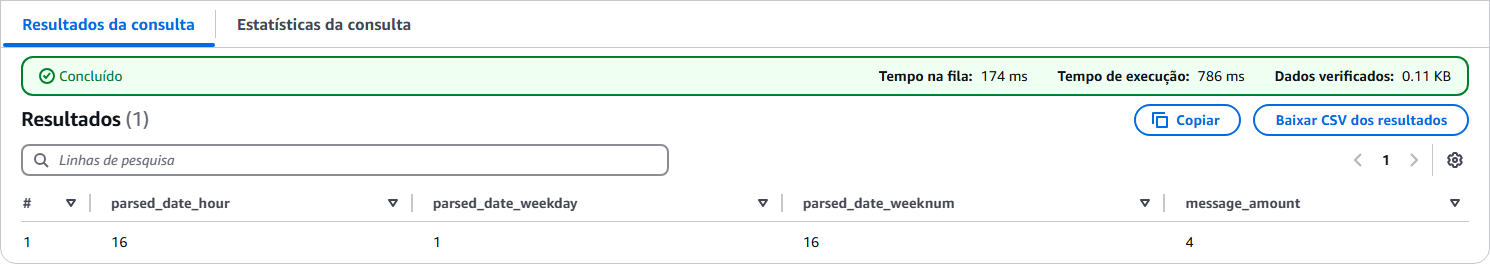

> **Análise:** Na 16ª hora do dia foram enviadas 4 mensagens.

## **5. Conclusão**

A plataforma do Telegram com a análise de dados e o uso de plataformas em nuvem, como a AWS, otimiza de forma expressiva as operações empresariais. O Telegram, com sua interface ágil disponível 24 horas por dia, simplifica a interação do cliente. O emprego da AWS intensifica essa interação ao oferecer escalabilidade, flexibilidade e confiabilidade, com ajustes dinâmicos de recursos conforme a demanda.

A análise de dados, impulsionada por pipelines na nuvem, torna-se ainda mais eficiente com essa abordagem, proporcionando processamento em grande escala e armazenamento seguro. Isso possibilita a extração de insights detalhados a partir de volumes substanciais de informações geradas pelas interações dos usuários no Telegram.

As vantagens incluem também a redução de custos pela nuvem, eliminando a necessidade de investir em infraestrutura física, e a agilidade na adaptação a mudanças nas demandas operacionais, garantindo eficiência contínua. A segurança não pode ser deixada de lado, especialmente ao lidar com informações do cliente em interações na plataforma. Plataformas em nuvem, como a AWS, implementam protocolos rigorosos, protegendo dados sensíveis contra ameaças cibernéticas.

Em resumo, essa integração proporciona uma abordagem sinérgica que aprimora a experiência do cliente no Telegram, otimiza a eficiência operacional e oferece suporte estratégico para tomada de decisões. A aplicação de um pipeline de análise de dados desempenha um papel fundamental no cenário corporativo, fornecendo recursos para impulsionar inovação e excelência.